# Simple example on how to perform and interpret simulated attacks

This is an example on how that show a how to create a very simple AI/ML model with generic data. Once the model is trained, it is wrapped with the `Target` class to perform simulated attacks and generated a report from the attacks.

For the purpose of training, this example shows a high risk model, which under most circumstances will not be egressed from a TRE.

## Installation 

For this example, we will install all the necessary python packages within this notebook. Ideally, a virtual environment should be created (conda, anaconda, venv, etc.) and install all the packages within it.

If you already have one, and have all the following packages installed, skip the next cell. Activate that environment and run the Jupyter notebook within it. 

Otherwise, uncomment and run the cell below. Note that the installation can take several minutes.

In [ ]:
#%pip install sacroml

## Loading modules

Load all the necessary modules for this example.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sacroml.attacks.structural_attack import StructuralAttack
from sacroml.attacks.likelihood_attack import LIRAAttack
from sacroml.attacks.target import Target

# Create a dummy model

First load data, then split it into training and test sets with a minimum of 30% of data for testing. This is essential for 2 reason: (i) to ensure model evaluation and (ii) to enable disclosure control. Without this split models cannot be tested and will not be egressed from a TRE.

In [2]:
# Load dataset
X, y = load_breast_cancer(return_X_y=True, as_frame=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In this example we create a Random Forest model.

In [3]:
# Fit model
model = RandomForestClassifier(min_samples_split=2, min_samples_leaf=1)
model.fit(X_train, y_train)

RandomForestClassifier()

# Privacy risk assessment

Wrap the model, the train and target data and labels with the Target class. This enables a faster and esier option to evaluate the privacy risks of the model created.

In [4]:
# Wrap model and data
target = Target(
    model=model,
    dataset_name="breast cancer",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

## First line of checks

Some configurations in some datasets can immediately lead to potential data leakage. It is vital to ensure the model to be egressed passes this first line of checks successfully.

The structural attacks is an assessment of privacy risks. It checks for structural issues with the model that can lead to potential data breaches. It is based on the static structure of a model. Performs structural privacy risk assessments on trained AI/ML models. This assessment is based on model architecture and hyperparameters, aligned with TRE risk appetite for ‘traditional’ outputs.

It includes checks for: - Residual Degrees of freedom - Complexity risk - and uses Equivalence class analysis to identify risks of K-anonymity and Class disclosure (partitions of decision space with zero probability for some labels) - Reidentification through small groups (partitions of decision space with some groups below the cell count threshold).

First need to check that your model is supported to run the structural privacy risk assessment.

In [5]:
StructuralAttack.attackable(target)


True

If True, then run the structural privacy risk assessment. This should run previous to any other simulated attacks. It detects immediate red flags that should be dealt with if detected. Once this check is all good, you can move to the next level of risk assessment.

In [6]:

structural_attack = StructuralAttack(output_dir="structural_privacy_risk_example")
structural_attack.attack(target)

INFO:acro:version: 0.4.9
INFO:acro:config: {'safe_threshold': 10, 'safe_dof_threshold': 10, 'safe_nk_n': 2, 'safe_nk_k': 0.9, 'safe_pratio_p': 0.1, 'check_missing_values': False, 'survival_safe_threshold': 10, 'zeros_are_disclosive': True}
INFO:acro:automatic suppression: False
INFO:sacroml.attacks.structural_attack:Thresholds for count 10 and Dof 10
INFO:sacroml.attacks.attack:Generating report
INFO:sacroml.attacks.attack:Writing report: structural_privacy_risk_example\report.json structural_privacy_risk_example\report.pdf
INFO:sacroml.attacks.structural_attack:PDF report not yet implemented for Structural attack


{'log_id': 'cd2ee735-1b5a-4b28-ab05-3ee834cf66d1',
 'log_time': '05/05/2026 12:19:58',
 'metadata': {'sacroml_version': '1.4.0',
  'attack_name': 'Structural attack',
  'attack_params': {'output_dir': 'structural_privacy_risk_example',
   'write_report': True,
   'risk_appetite_config': 'default'},
  'global_metrics': {'dof_risk': np.True_,
   'k_anonymity_risk': np.True_,
   'class_disclosure_risk': np.True_,
   'unnecessary_risk': True,
   'lowvals_cd_risk': np.False_},
  'target_model': 'RandomForestClassifier',
  'target_model_params': {},
  'target_train_params': {}},
 'attack_experiment_logger': {'attack_instance_logger': {},
  'dof_risk': np.True_,
  'k_anonymity_risk': np.True_,
  'class_disclosure_risk': np.True_,
  'unnecessary_risk': True,
  'lowvals_cd_risk': np.False_}}

The results shows that the models passes the checks for:
- Class disclosure: meaning that is unlikely the model accidentally reveals some facts about the data.

The assessment shows some potential risks:
- K anonymity and class disclosure risk: the model could potentially reveal data belonging to small groups of records.

## Evaluation of data leakage under malicious attack

Even if the first line of privacy checks comes green, there are other risks that must be evaluated previous to a model egress. Once models are released from the TRE they may become potential targets to malicious attackers. It is important to ensure the risk of data breach are minimised under such circumstances.

SACROM-ML has implemented simulated attacks to estimate the risks of the model under such circumstances.

### Likelyhood Ratio Attack (LiRA)

The most advanced and statistically strong attack. It trains many "shadow" models to learn subtle differences in how the model behaves on seen vs. unseen data, then uses a likelihood ratio test.

It estimated the capability of an attacker to correctly identify records (all the information to relating to one or more people) that was used during the training phase.


INFO:sacroml.attacks.likelihood_attack:new y_train has values and counts: (array([0, 1]), array([149, 249]))
INFO:sacroml.attacks.likelihood_attack:new y_test has values and counts: (array([0, 1]), array([ 63, 108]))
INFO:sacroml.attacks.likelihood_attack:Running offline LiRA, fix_variance=False
INFO:sacroml.attacks.likelihood_attack:Training shadow models
INFO:sacroml.attacks.likelihood_attack:Trained 0 models
INFO:sacroml.attacks.likelihood_attack:Trained 10 models
INFO:sacroml.attacks.likelihood_attack:Trained 20 models
INFO:sacroml.attacks.likelihood_attack:Trained 30 models
INFO:sacroml.attacks.likelihood_attack:Trained 40 models
INFO:sacroml.attacks.likelihood_attack:Trained 50 models
INFO:sacroml.attacks.likelihood_attack:Trained 60 models
INFO:sacroml.attacks.likelihood_attack:Trained 70 models
INFO:sacroml.attacks.likelihood_attack:Trained 80 models
INFO:sacroml.attacks.likelihood_attack:Trained 90 models
INFO:sacroml.attacks.likelihood_attack:Computing scores
INFO:sacroml.att

{'log_id': 'd39d8795-1908-43c7-b9ee-67f532ca4d2b',
 'log_time': '05/05/2026 12:20:19',
 'metadata': {'sacroml_version': '1.4.0',
  'attack_name': 'LiRA Attack',
  'attack_params': {'output_dir': 'output_example',
   'write_report': True,
   'n_shadow_models': 100,
   'p_thresh': 0.05,
   'mode': 'offline',
   'fix_variance': False,
   'report_individual': False},
  'global_metrics': {'PDIF_sig': 'Significant at p=0.05',
   'AUC_sig': 'Significant at p=0.05',
   'null_auc_3sd_range': '0.4207446718814698 -> 0.5792553281185302'},
  'target_model': 'RandomForestClassifier',
  'target_model_params': {},
  'target_train_params': {}},
 'attack_experiment_logger': {'attack_instance_logger': {'instance_0': {'TPR': 0.71105528,
    'FPR': 0.44444444,
    'FAR': 0.21169916,
    'TNR': 0.55555556,
    'PPV': 0.78830084,
    'NPV': 0.45238095,
    'FNR': 0.28894472,
    'ACC': 0.66432337,
    'F1score': 0.74768825,
    'Advantage': 0.26661083999999996,
    'AUC': np.float64(0.7242499),
    'P_HIGHER

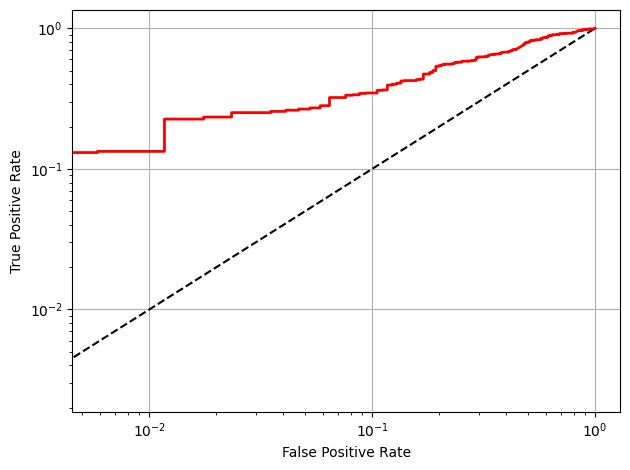

In [7]:
# Create an attack object and run the attack
# ensure Structural attack is also created 
attack = LIRAAttack(n_shadow_models=100, output_dir="output_example")

attack.attack(target)

The LiRA results shows that:
- Some general metrics are borderline e.g. TPR or ACC (Accuracy). Thresholds can be set on risk appetite TRE-project dependant.
- The AUC of the attack is significant.
- The metrics PDIF, designed for disclosure risk, is significant. This means that some records will be disclosed under malicious attack.
- The metric TPR at specific low FPR is high, also signals that some records will be disclosed under malicious attack.

# Conclusions

The model is wrapped in the "Target" object, which enables a faster and easier assessment of the privacy risks.

This model is high risk and is very likely that a data breach can occur. It failed both assessments, the structural risks and the simulated malicious attacks.

The model hyperparameters should be changed prior requesting a model egress or if it has been requested, the TRE operator will refuse the egress of the model.